# Business Sales Performance Analysis

## Objective
Analyze sales data to identify revenue trends, top-performing products, revenue by catagory and regional performance to support business decision-making.

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Monwabisi05\IdeaProjects\DATA SCIENCE_FUTURE_DS_01\Task1\Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning

- Checked for missing values
- Removed duplicates
- Converted date columns to datetime format
- Check data types
- Handle missing values (if any)
- Check for negative profit

In [2]:
df.isnull().sum()
df.drop_duplicates(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.info()
df.fillna(0, inplace=True)
loss_df = df[df['Profit'] < 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## Imports and Loading

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_style("whitegrid")
sns.set_context("talk")
# 1️. Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])


## Revenue Trend Analysis

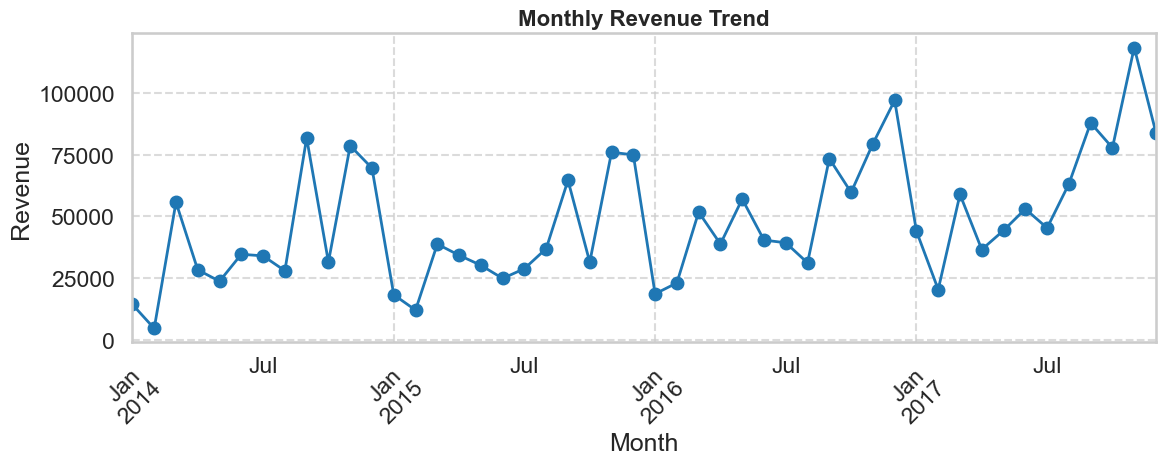

In [7]:

# Aggregate sales on a monthly basis to identify revenue trends over time
monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum()
# Create figure
plt.figure(figsize=(12,5))
# Plot
monthly_sales.plot(marker='o', linewidth=2)

# Titles and labels
plt.title("Monthly Revenue Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Insight:
Revenue fluctuates over time with noticeable peaks in certain months, suggesting seasonal demand patterns or promotional effects.

## Top 10 Products by Revenue Analysis

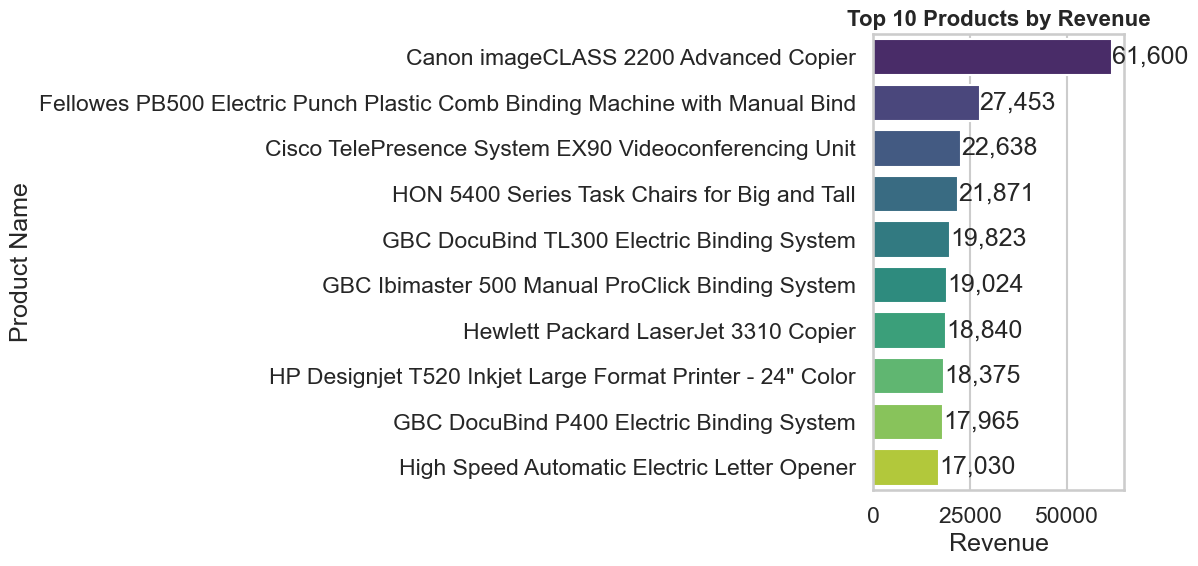

In [8]:

#Calculate total sales per product
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Convert to DataFrame for visualization
top_products_df = top_products.reset_index()
top_products_df.columns = ['Product Name', 'Sales']

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_products_df,
    x='Sales',
    y='Product Name',
    hue='Product Name',
    palette='viridis',
    legend=False
)

plt.title("Top 10 Products by Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Revenue")
plt.ylabel("Product Name")

# Add value labels
for index, value in enumerate(top_products_df['Sales']):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.tight_layout()
plt.show()

###  Insight:
A small number of products contribute largely to a portion of total revenue, indicating a strong dependency on high-performing products. This suggests that inventory and marketing strategies should prioritize these key items.

## Category Performance

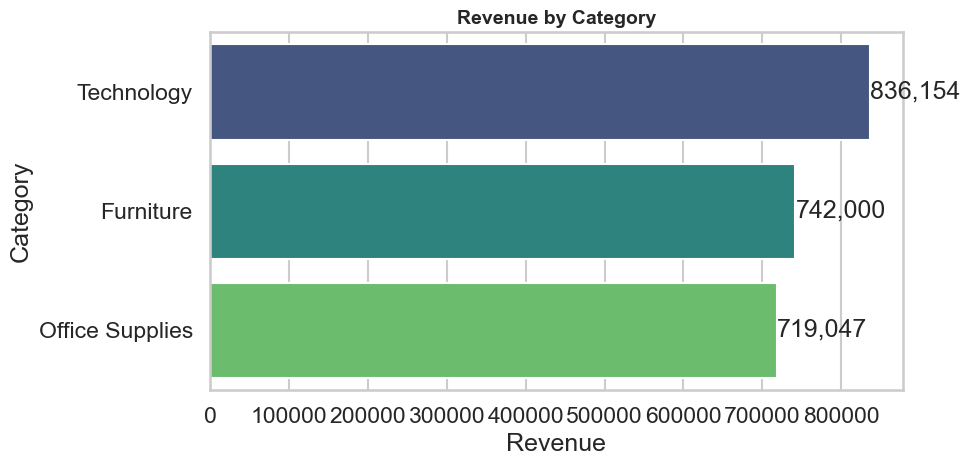

In [44]:
# 4️. Revenue by Category
plt.figure(figsize=(10,5))

category_df = category_sales.reset_index()
category_df.columns = ['Category', 'Sales']

# Sort for better visuals
category_df = category_df.sort_values(by='Sales', ascending=False)

sns.barplot(
    data=category_df,
    x='Sales',
    y='Category',
    hue='Category',
    palette='viridis',
    legend=False
)

plt.title("Revenue by Category", fontsize=14, fontweight='bold')
plt.xlabel("Revenue")
plt.ylabel("Category")

# Add value labels
for index, value in enumerate(category_df['Sales']):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.tight_layout()
plt.show()

### Insight:
Technology is the highest revenue-generating category, followed by Furniture and Office Supplies.

## Regional Performance

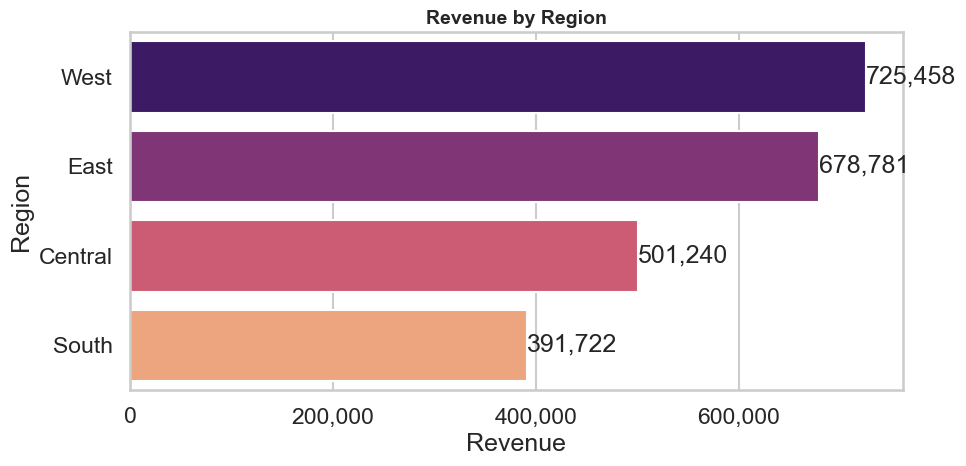

In [10]:
# Revenue by Region
plt.figure(figsize=(10,5))

region_df = df.groupby('Region')['Sales'].sum().reset_index()
region_df = region_df.sort_values(by='Sales', ascending=False)

sns.barplot(
    data=region_df,
    x='Sales',
    y='Region',
    hue='Region',
    palette='magma',
    legend=False
)

plt.title("Revenue by Region", fontsize=14, fontweight='bold')
plt.xlabel("Revenue")
plt.ylabel("Region")

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.locator_params(axis='x', nbins=6)

for index, value in enumerate(region_df['Sales']):
    plt.text(value, index, f'{value:,.0f}', va='center')

plt.tight_layout()
plt.show()

### Insight:
The West region leads in revenue, while the South region shows the lowest performance.

## Final Recommendations

- Focus on top-performing products to maximize revenue
- Invest more in the Technology category
- Improve sales strategies in underperforming regions
- Use seasonal trends to plan marketing campaigns